В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [ ]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/hse-ds/iad-intro-ds/master/2024/homeworks/hw06_texts/tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
24170,33346,78298,"Southampton, NY",05-04-2020,These rich assholes still go to the grocery st...,Negative
3232,7707,52659,NaN,18-03-2020,"""We're going to be open,"" Sonny's Super Foods ...",Negative
7356,12729,57681,"Windsor, berkshire",20-03-2020,Pour any kegged beer into a 500ml can to take ...,Extremely Positive
3965,8620,53572,"London, UK",18-03-2020,Please be kind to the supermarket workers who ...,Extremely Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная эмоциональная окраска и 0 - если отрицательная.

In [ ]:
val_sent = df.Sentiment.unique()
df.head(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,Positive
5,3805,48757,"35.926541,-78.753267",16-03-2020,Cashier at grocery store was sharing his insig...,Positive
6,3807,48759,"Atlanta, GA USA",16-03-2020,Due to COVID-19 our retail store and classroom...,Positive
7,3808,48760,"BHAVNAGAR,GUJRAT",16-03-2020,"For corona prevention,we should stop to buy th...",Negative
8,3810,48762,"Pitt Meadows, BC, Canada",16-03-2020,"Due to the Covid-19 situation, we have increas...",Extremely Positive
9,3811,48763,Horningsea,16-03-2020,#horningsea is a caring community. LetÃÂs AL...,Extremely Positive


In [ ]:
for val in val_sent:
    if val == 'Positive' or val == 'Extremely Positive':
        df.loc[df['Sentiment'] == val, ['Sentiment']] = 1
    else:
        df.loc[df['Sentiment'] == val, ['Sentiment']] = 0
df.head(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1
5,3805,48757,"35.926541,-78.753267",16-03-2020,Cashier at grocery store was sharing his insig...,1
6,3807,48759,"Atlanta, GA USA",16-03-2020,Due to COVID-19 our retail store and classroom...,1
7,3808,48760,"BHAVNAGAR,GUJRAT",16-03-2020,"For corona prevention,we should stop to buy th...",0
8,3810,48762,"Pitt Meadows, BC, Canada",16-03-2020,"Due to the Covid-19 situation, we have increas...",1
9,3811,48763,Horningsea,16-03-2020,#horningsea is a caring community. LetÃÂs AL...,1


Сбалансированы ли классы?

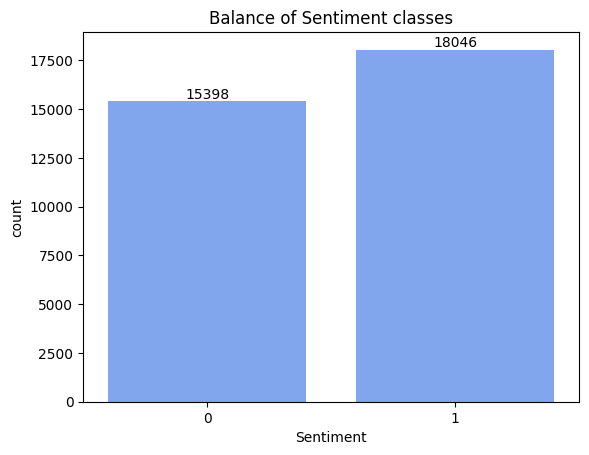

In [ ]:
classes_sent = df['Sentiment'].value_counts()
ax = sns.barplot(classes_sent, color = '#70a0ff')
ax.bar_label(ax.containers[0])
plt.title('Balance of Sentiment classes')
plt.show()

**Ответ:** В целом классы сбалансированны, первый класс ~ на 15% меньше второго

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [ ]:
df.isna().sum() # в колонке Location есть пропуски

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [ ]:
df.fillna('Unknown', inplace = True)

Разделите данные на обучающие и тестовые в соотношении 7 : 3 и `random_state=0`

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size = 0.3, random_state=0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведение токенов в нижний регистр

In [ ]:
from collections import Counter
texts_tw = ' '.join(train['OriginalTweet'].tolist())
tweets = texts_tw.lower()
words = tweets.split()
tokens_df = pd.DataFrame(Counter(words).items(), columns = ['word', 'count'])
dictionary = tokens_df['word'].tolist()
tokens_df.head()

,word,count
0,why,654
1,we,3787
2,still,763
3,want,487
4,to,23373


Какой размер словаря получился?

In [ ]:
print(f'Размер словаря = {len(dictionary)}')

Размер словаря = 79755


Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе

In [ ]:
tokens_sort = tokens_df.sort_values(by = ['count'], ascending = False)
tokens_sort.head(10)

,word,count
54,the,26815
4,to,23373
29,and,14684
129,of,13012
20,a,11737
141,in,11198
204,for,8566
69,#coronavirus,8223
23,is,7383
89,are,7050


**Ответ:** Эти токены скорее всего являются очень распространенными словами в любых текстах и речи (предлоги, артикли, вспомогательные глаголы). Среди них затесался хештег #coronavirus, судя по названию файла (tweets_coronavirus), это основная тема твитов, поэтому он тоже popular.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)
dictionary2 = list(set(dictionary) - set(stopwords.words("english")))
tokens_df2 = tokens_df.loc[tokens_df['word'].isin(dictionary2)]
tokens2_sort = tokens_df2.sort_values(by = ['count'], ascending = False)
tokens2_sort.head(10)

,word,count
69,#coronavirus,8223
432,prices,3891
99,food,3820
85,grocery,3469
202,supermarket,3288
91,people,3175
144,covid-19,3173
183,store,3155
198,#covid19,2471
636,&amp;,2314


**Ответ:**  Теперь самые популярные токены отражают - это хештеги про ковид и слова, тесно связанные с темой коронавируса (ограничения в магазинах, растущие цены), и еще неизвестный мне & amp;, который как-то связан с HTML.

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [ ]:
tokens2_sort.tail(20)

,word,count
37740,466,1
37741,pmt,1
37743,acres,1
37744,cucumber,1
37746,https://t.co/x69jqbisox,1
37748,had!,1
37752,massive.,1
37767,https://t.co/6ytxpz5ug9,1
37753,https://t.co/l8jnzxjgwo,1
37754,"readiness,",1


**Ответ:** Многие слова "слились" со знаками препинания ((covid-19, had!), поэтому они распознаются как отдельные слова: следует разделять слова от знаков препинания (в этом беда split-а).

 Также есть редкие слова, которые не дают никакой информации, так как по ним вряд ли можно оценить эмоциональную окраску текста (они больше нигде не встречаются).

 И различные числа, ссылки, которые скорее нужно выкинуть, они не несут никакого смысла в задаче определения окраски текста.



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [ ]:
from nltk.tokenize import TweetTokenizer

tw_tk = TweetTokenizer()
words_tw = tw_tk.tokenize(tweets)
tokens_tw = pd.DataFrame(Counter(words_tw).items(), columns = ['word', 'count'])
tokens_tw_sort = tokens_tw.sort_values(by = ['count'], ascending = False)
tokens_tw_sort.head(10)

,word,count
55,the,26993
57,.,24108
4,to,23478
95,",",17571
29,and,14825
140,of,13044
20,a,11891
152,in,11348
103,?,9524
76,#coronavirus,8808


**Ответ:** Топ слов остался тем же (если сравнивать с предыдущим до выкидывания стоп-слов), так как эти слова в целом чаще употребляются. Но знаки препинания вынеслись в отдельные слова из-за смены метода токенизации, поэтому они тоже фигурируют в топе (это ".", "?", ",", так как они чаще всего употребляются в предложениях)

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [ ]:
from string import punctuation

noise = list(punctuation) + stopwords.words("english")
dict_tw = tokens_tw['word'].tolist()
dict_tw2 = list(set(dict_tw) - set(noise))
tokens_tw2 = tokens_tw.loc[tokens_tw['word'].isin(dict_tw2)]
tokens_tw2_sort = tokens_tw2.sort_values(by = ['count'], ascending = False)
tokens_tw2_sort.head(10)

,word,count
76,#coronavirus,8808
73,â,7415
72,,7311
157,19,7167
155,covid,6253
433,prices,4601
74,,4372
109,food,4367
93,store,3877
217,supermarket,3805


**Ответ:** В топе есть какие-то квадратики (видимо, символы не отображаются), буквы не из латиницы и цифры (19 здесь - от covid-19).

Удалите из словаря токены из одного символа, с позицией в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [ ]:
tokens_tw3 = tokens_tw2.drop(tokens_tw2.loc[tokens_tw2['word'].apply(lambda x: (len(x) == 1) and (ord(x) >= 128))].index)
tokens_tw3_sort = tokens_tw3.sort_values(by = ['count'], ascending = False)
tokens_tw3_sort.head(10)

,word,count
76,#coronavirus,8808
157,19,7167
155,covid,6253
433,prices,4601
109,food,4367
93,store,3877
217,supermarket,3805
92,grocery,3523
99,people,3463
213,#covid19,2589


In [ ]:
tokens_tw3_sort.tail(20)

,word,count
28545,@awgcorporate,1
28520,https://t.co/l8jnzxjgwo,1
28530,587-4272,1
28521,readiness,1
28522,kick-in,1
28523,https://t.co/wa7kcdwqea,1
28524,@linkedin,1
28526,clare,1
28527,connors,1
28529,levins,1


**Ответ:**

В топ-10 слова практически такие же, но теперь частота каждого выше, так как многие отделились от знаков препинания - это плюс. Однако в текущем топе от covid отделилось число 19, причем оно встречается чаще, чем covid. Возможно, в твитах, где 19 используется без привязки к коронавирусу, оно может неправильно трактоваться.

В топ-20 непопулярных слов теперь нет слипшихся слов со знаками препинания, это улучшение токенизации. Теперь здесь только ссылки, очень редкие слова и какие-то числа.

Выведите топ-10 популярных хештегов с количеством встреч. Что можно сказать о них?

In [ ]:
tokens_tw3_sort.loc[tokens_tw3_sort['word'].apply(lambda x: x[0] == '#')].head(10)

,word,count
76,#coronavirus,8808
213,#covid19,2589
13,#covid_19,1734
863,#covid2019,946
144,#toiletpaper,744
993,#covid,641
891,#socialdistancing,465
190,#coronacrisis,448
1152,#pandemic,257
3120,#coronaviruspandemic,249


**Ответ:** Все хештеги связаны с пандемией коронавируса (туалетная бумага, наверно, была в дефиците :))))

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [ ]:
tokens_tw3_sort.loc[tokens_tw3_sort['word'].apply(lambda x: x[:12] == 'https://t.co')].head(10)

,word,count
16096,https://t.co/oxa7swtond,5
2335,https://t.co/gp3eusapl8,4
23903,https://t.co/g63rp042ho,3
13817,https://t.co/e2znxajpre,3
45278,https://t.co/oi39zsanq8,3
28647,https://t.co/bylqxrjmnt,3
22724,https://t.co/catkegayoy,3
31060,https://t.co/wuieefsnoj,3
6670,https://t.co/deftrui1pfãâ,3
9024,https://t.co/kuwipf1kqw,3


**Ответ:** Популярность ссылок не сравнима с популярностью хештегов, максимальная частота - 5 повторений. Само название ссылки ни о чем не говорит, а так как их частота очень маленькая, то и ссылание на одну и ту же ссылку не особо влияет (потому что таких случаев очень мало), и использование ссылок в определении эмоциональной окраски текста бесполезно.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для изначального выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа, с позицией в таблице Unicode 128 и более и ссылки на t.co



In [ ]:
def custom_tokenizer(text):

  text = text.lower()
  tw = TweetTokenizer()
  text2 = tw.tokenize(text)
  text3 = [word for word in text2 if word not in noise]
  #un128 = [elem for elem in text3 if (len(elem) == 1) and ord(elem) >= 128]
  text4 = [elem for elem in text3 if not ((len(elem) == 1) and ord(elem) >= 128)]
  tokens = [item for item in text4 if item[:12] !='https://t.co']
  return tokens


In [ ]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
vec = cv.fit_transform(train['OriginalTweet'])

print(len(cv.vocabulary_))

45308


**Ответ:** Изначально было 79755 токенов, стало 45308 - размер словаяр сильно уменьшился. Это следствие более осмысленного подхода к токенизации текстов, так как много ненужных слов и элементов было удалено.

Посмотрим на какой-нибудь конкретный твитт:

In [ ]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 0)

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [ ]:
bow = cv.transform([train.iloc[ind]['OriginalTweet']])
bow2 = bow.toarray()
print(f'Все частоты в данном твите: {np.unique(bow2)}')
print(f'Токены, где частота равна 1: {cv.get_feature_names_out()[np.where(bow2 == 1)[1]]}')

Все частоты в данном твите: [0 1]
Токены, где частота равна 1: ['#coronavirusoutbreak' '#covid2019' '@skynews' 'brainless' 'ffs' 'food'
 'france' 'lets' 'nice' 'one' 'panic' 'ppl' 'queueing' 'show']


**Ответ:** В данном твите каждый токен встречается не более одного раза, поэтому самый важный и самый неважный токен не определяются, все равнозначны (именно по частоте)

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tv = TfidfVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
vec2 = tv.fit_transform(train['OriginalTweet'])

In [ ]:
vec_tfidf = tv.transform([train.iloc[ind]['OriginalTweet']])
vec_tfidf2 = vec_tfidf.toarray()
print(f'Все относительные частоты в данном твите: {np.unique(vec_tfidf2)}')
token_max = np.argmax(vec_tfidf2)
token_min = np.argmin(vec_tfidf2[vec_tfidf2 != 0])
token_min2 = np.nonzero(vec_tfidf2)[1][token_min]
print(f'Самый важный токен: {tv.get_feature_names_out()[token_max]}')
print(f'Самый неважный токен: {tv.get_feature_names_out()[token_min2]}')

Все относительные частоты в данном твите: [0.         0.11328893 0.1475947  0.16306723 0.16825193 0.22584265
 0.24406492 0.25427292 0.25500646 0.3012107  0.31042634 0.32047314
 0.32447418 0.35434556 0.38676412]
Самый важный токен: brainless
Самый неважный токен: food


**Ответ:** Brainless имеет наибольшую относительную частоту - и это действительно важный токен, так как с высокой вероятностью, если он есть в тексте, то твит несет негативный посыл.

Food, наоборот, самый неважный токен, так как он встречается в большом количестве твитов, и по нему тяжело определять: негативный или позитивный эмоциональный окрас у текста.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [ ]:
np.random.seed(69)
train[train['OriginalTweet'].apply(lambda x: 'grateful' in x) & (train['Sentiment'] == 1)].sample(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
5274,10212,55164,"London, England",19-03-2020,So grateful to @POTAGELONDON today. Not only w...,1
27501,37524,82476,"England, United Kingdom",08-04-2020,The #CoronaCrisis is making subtle changes to ...,1
7516,12919,57871,"Boston, MA",20-03-2020,I ?? this Ellie. Amid the #coronavirus outbrea...,1
7395,12776,57728,SLC/DC/Detroit Rock City,20-03-2020,One positive out of #CoronaCrisis is that when...,1
3605,8180,53132,"Fort Wayne, Indiana",18-03-2020,Sending a special thank you to all healthcare ...,1
3709,8300,53252,Unknown,18-03-2020,Never thought I would be grateful to #Walmart ...,1
23473,32471,77423,LDN,05-04-2020,You can t be grateful to God without also bein...,1
30811,41697,86649,"Austin, TX",11-04-2020,Two important ways to help maintain #SocialDis...,1
22045,30720,75672,Unknown,02-04-2020,"Supermarket workers, bin men, DWP workers are ...",1
21834,30450,75402,Unknown,02-04-2020,Shouldn't world's leading 'free market' econom...,1


In [ ]:
pos_tw = train['OriginalTweet'].loc[7516]
pos_tw

'I ?? this Ellie. Amid the #coronavirus outbreak IÃ\x82Â\x92m grateful for those on the front lines: doctors, nurses, assistants, scientists... also police, firefighters, grocery store workers, garbage truck drivers, etc. helping us all cope....\r\r\n\r\r\nSHARE: What are you grateful for? https://t.co/ug7glSp4rJ'

In [ ]:
pos_vec = tv.transform([pos_tw])
pos_vec2 = pos_vec.toarray()
print(f'Все относительные частоты в данном твите: {np.unique(pos_vec2)}')
pos_max = np.argmax(pos_vec2)
pos_min = np.argmin(pos_vec2[pos_vec2 != 0])
pos_min2 = np.nonzero(pos_vec2)[1][pos_min]
print(f'Самый важный токен: {tv.get_feature_names_out()[pos_max]}')
print(f'Самый неважный токен: {tv.get_feature_names_out()[pos_min2]}')

Все относительные частоты в данном твите: [0.         0.05851862 0.08415711 0.08673153 0.11404129 0.11433008
 0.13487546 0.13546345 0.13989113 0.13999748 0.15899833 0.16024111
 0.16220928 0.16555833 0.16779414 0.17096429 0.17173487 0.17284865
 0.17333917 0.18936387 0.21408665 0.2198634  0.22951461 0.23263796
 0.23657869 0.27893047 0.30597176 0.4055678 ]
Самый важный токен: grateful
Самый неважный токен: #coronavirus


**Ответ:** Очень долго я искала твит, где модель выделяла бы не какие-то редкие слова (типа "мусор", или "#собака"), а нормальный токен, и наконец нашла!!

В данном примере самым важным по относительной частоте токеном стал grateful, и это оправданно: grateful очень хорошо подходит под описание положительно окрашенного слова, значит, он должен иметь больший вес по сравнению с другими словами (в данном твите больше нет явно положительных слов)

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [ ]:
y_train = train['Sentiment']
y_test = test['Sentiment']
X_train = train['OriginalTweet']
X_test = test['OriginalTweet']
vec_cv_train = cv.fit_transform(X_train)
vec_cv_test = cv.transform(X_test)

vec_tv_train = tv.fit_transform(X_train)
vec_tv_test = tv.transform(X_test)

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=200, random_state=0)
clf.fit(vec_cv_train, y_train)
pred_train = clf.predict(vec_cv_train)
pred_test = clf.predict(vec_cv_test)
print('CountVectorizer:')
print(f'Доля правильных ответов на train = {accuracy_score(pred_train, y_train)}')
print(f'Доля правильных ответов на test = {accuracy_score(pred_test, y_test)}')

CountVectorizer:
Доля правильных ответов на train = 0.9844510892780863
Доля правильных ответов на test = 0.8672513454255532


In [ ]:
clf.fit(vec_tv_train, y_train)
pred_train2 = clf.predict(vec_tv_train)
pred_test2 = clf.predict(vec_tv_test)
print('TfidfVectorizer:')
print(f'Доля правильных ответов на train = {accuracy_score(pred_train2, y_train)}')
print(f'Доля правильных ответов на test = {accuracy_score(pred_test2, y_test)}')

TfidfVectorizer:
Доля правильных ответов на train = 0.9254592054677488
Доля правильных ответов на test = 0.8533984452860275


**Ответ:** У обеих моделей высокие показатели accuracy, но CountVectorizer справился лучше, чем TF-IDF, что неожиданно, так как по идее TF-IDF позволяет выделить ключевые слова и уменьшить влияние часто встречающихся слов, и обычно показывает результаты лучше, чем Bag-of-words. Возможно, это специфика данных, TF-IDF может выделять совсем редкие слова, которые не совсем информативны.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [ ]:
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer("english")
def custom_stem_tokenizer(text):
  text = custom_tokenizer(text.lower())
  tokens = [stemmer.stem(i) for i in text]
  return tokens

In [ ]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [ ]:
cv2 = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
tv2 = TfidfVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)

vec_cv2_train = cv2.fit_transform(X_train)
vec_cv2_test = cv2.transform(X_test)

vec_tv2_train = tv2.fit_transform(X_train)
vec_tv2_test = tv2.transform(X_test)

print(f'Длина словаря = {len(cv2.vocabulary_)}')
print(f'Размер словаря снизился на {len(cv.vocabulary_) - len(cv2.vocabulary_)}')

Длина словаря = 36652
Размер словаря снизился на 8656


**Ответ** Размер словаря снизился, так как многие слова объединились в один токен (типа run, running, runs)

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [ ]:
clf.fit(vec_cv2_train, y_train)
pred_train_stem = clf.predict(vec_cv2_train)
pred_test_stem = clf.predict(vec_cv2_test)
print('CountVectorizer:')
print(f'Доля правильных ответов на train = {accuracy_score(pred_train_stem, y_train)}, изменилась на {round((accuracy_score(pred_train_stem, y_train) - accuracy_score(pred_train, y_train)) / accuracy_score(pred_train, y_train), 4) * 100}%')
print(f'Доля правильных ответов на test = {accuracy_score(pred_test_stem, y_test)}, изменилась на {(accuracy_score(pred_test_stem, y_test) - accuracy_score(pred_test, y_test)) / accuracy_score(pred_test, y_test) * 100}%')

CountVectorizer:
Доля правильных ответов на train = 0.9718923536950022, изменилась на -1.28%
Доля правильных ответов на test = 0.8672513454255532, изменилась на 0.0%


In [ ]:
clf.fit(vec_tv2_train, y_train)
pred_train_stem2 = clf.predict(vec_tv2_train)
pred_test_stem2 = clf.predict(vec_tv2_test)
print('TfidfVectorizer:')
print(f'Доля правильных ответов на train = {accuracy_score(pred_train_stem2, y_train)}, изменилась на {round((accuracy_score(pred_train_stem2, y_train) - accuracy_score(pred_train2, y_train)) / accuracy_score(pred_train2, y_train), 4) * 100}%')
print(f'Доля правильных ответов на test = {accuracy_score(pred_test_stem2, y_test)}, изменилась на {round((accuracy_score(pred_test_stem2, y_test) - accuracy_score(pred_test2, y_test)) / accuracy_score(pred_test2, y_test), 4) * 100}%')

TfidfVectorizer:
Доля правильных ответов на train = 0.9158906450234943, изменилась на -1.03%
Доля правильных ответов на test = 0.8560892963922663, изменилась на 0.32%


**Ответ:** Стемминг ухудшил качество на трейне и немного улучшил на тесте во второй модели. Но изменения совсем незначительны, нет смысла применять стемминг, тем более для CountVectorizer.

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [ ]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        token_pattern=None,
                        max_df=0.3
                        ).fit(
                            X_train
                            )
print(len(cv_df.vocabulary_))

36651


In [ ]:
for i in [0.1, 0.2, 0.3, 0.4, 0.5]:
    cv_df0 = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None,
                        max_df=i
                        ).fit(
                            X_train
                            )
    print(len(cv_df0.vocabulary_), i)
print('При значении max_df = 0.3 размер словаря = 36651')

36640 0.1
36649 0.2
36651 0.3
36652 0.4
36652 0.5
При значении max_df = 0.3 размер словаря = 36651


**Ответ:** Значение max_df получилось небольшим: 0.3, так как каждый токен встречается не более, чем в 30% твитов (кроме одного токена). Этому во многом поспособствовало избавление от стоп-слов и пунктуации, которые вполне могли создавать шум своей высокой частотностью.

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [ ]:
for i in np.linspace(0, 0.001, 5):
    cv_df0 = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None,
                        min_df=i
                        ).fit(
                            X_train
                            )
    print(len(cv_df0.vocabulary_), i)

36652 0.0
5540 0.00025
3489 0.0005
2691 0.00075
2211 0.001


In [ ]:
for i in np.linspace(0.0003, 0.0005, 5):
    cv_df0 = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None,
                        min_df=i
                        ).fit(
                            X_train
                            )
    print(len(cv_df0.vocabulary_), i)
print('При значении min_df = 0.00045 размер словаря = 3700')

4522 0.0003
4199 0.00035
3931 0.00039999999999999996
3700 0.00045
3489 0.0005
При значении min_df = 0.00045 размер словаря = 3700


In [ ]:
cv_df2 = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None, min_df=0.00045)
vector_cv_train = cv_df2.fit_transform(X_train)
vector_cv_test = cv_df2.transform(X_test)
clf.fit(vector_cv_train, y_train)
predicted_cv_train = clf.predict(vector_cv_train)
predicted_cv_test = clf.predict(vector_cv_test)

print(f'Доля правильных ответов на train = {accuracy_score(predicted_cv_train, y_train)}')
print(f'Доля правильных ответов на test = {accuracy_score(predicted_cv_test, y_test)}')
print('Качество осталось примерно таким же')

Доля правильных ответов на train = 0.9286629645450662
Доля правильных ответов на test = 0.8680486346422165
Качество осталось примерно таким же


**Ответ:** С помощью подбора min_df отбросилось много ненужных токенов, которые встречаются менее, чем в 0.45% документов. Это позволило уменьшить размер словаря более, чем на 30000, сосредоточиться на более значимых словах, из-за чего может улучшиться интерпретируемость и увеличиться скорость, а также менее вероятно переобучение модели. При этом качество модели не ухудшилось.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `berplot` содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [ ]:
from sklearn.preprocessing import StandardScaler
cv_fin = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None, min_df=0.00045)
vector_cv_train_fin = cv_fin.fit_transform(X_train)
vector_cv_test_fin = cv_fin.transform(X_test)

scaler = StandardScaler()
vector_cv_train_fin = scaler.fit_transform(vector_cv_train_fin.toarray())
vector_cv_test_fin = scaler.transform(vector_cv_test_fin.toarray())

clf.fit(vector_cv_train_fin, y_train)
pred_train_fin = clf.predict(vector_cv_train_fin)
pred_test_fin = clf.predict(vector_cv_test_fin)

print(f'Доля правильных ответов на train = {accuracy_score(pred_train_fin, y_train)}')
print(f'Доля правильных ответов на test = {accuracy_score(pred_test_fin, y_test)}')

Доля правильных ответов на train = 0.9416915847928236
Доля правильных ответов на test = 0.8446282639027307


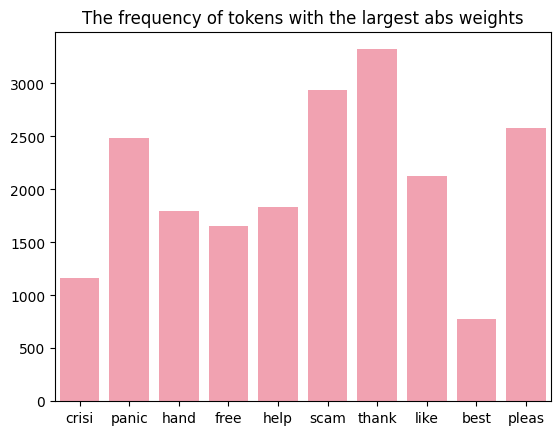

Токены ['crisi' 'panic' 'hand' 'free' 'help' 'scam' 'thank' 'like' 'best' 'pleas'], имеют веса соответственно [-1.75245347 -1.31194926  1.23176278  1.10829483  1.07896714 -1.06728827
  1.04381445  0.93208946  0.92220877  0.83967546]


In [ ]:
indexes = np.argsort(-abs(clf.coef_[0]))[:10]
tokens_maxw = cv_fin.get_feature_names_out()[indexes]
freq = [cv_fin.vocabulary_.get(i) for i in tokens_maxw]
sns.barplot(x=tokens_maxw, y=freq, color='#FE95A9')
plt.title('The frequency of tokens with the largest abs weights')
plt.show()
print(f'Токены {cv_fin.get_feature_names_out()[indexes]}, имеют веса соответственно {clf.coef_[0][indexes]}')

**Ответ:** Есть несколько токенов, которые скорее всего являются сигналами положительного окраса текста: thank, like, best, pleas, help; и отрицательного: panic, crisi, scam, их модель хорошо отобрала.

Токен free: вне контекста трудно оценить окрас (может быть, люди просили свободы, а может говорили о чем-то бесплатном, непонятно...). Однако в модели он имеет положительный коэффициент, значит, часто слово используют в контексте чего-то позитивного.

Токен hand я вообще не поняла, почему он имеет такой вес, как будто об окрасе он ничего не говорит, может быть встречается в твитах, где говорят мыть чаще руки, тогда это положительный окрас (но опять же неочевидно, вдруг там негативят на тех, кто не моет руки).

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [ ]:
df.head(6)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,Unknown,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,Unknown,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1
5,3805,48757,"35.926541,-78.753267",16-03-2020,Cashier at grocery store was sharing his insig...,1


In [ ]:
print(f'Уникальных значений UserName {df.UserName.nunique()}, ScreenName: {df.ScreenName.nunique()}, и всего твитов {df.shape[0]}')

Уникальных значений UserName 33444, ScreenName: 33444, и всего твитов 33444


**Ответ:** Признаки UserName и ScreenName ни о чем не говорят, это рандомные присваивания чисел именам пользователей, они не влияют на окраску текста (например, один и тот же пользователь мог оставить как положительный, так и отрицательный твит). Но, конечно, если у какого то пользователя все твиты отрицательные, то с большей вероятностю следующий его твит тоже отрицательный. Однаков в данном случае все юзернеймы и скриннеймы уникальны, поэтому здесь они роли не играют.

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на оспнове целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

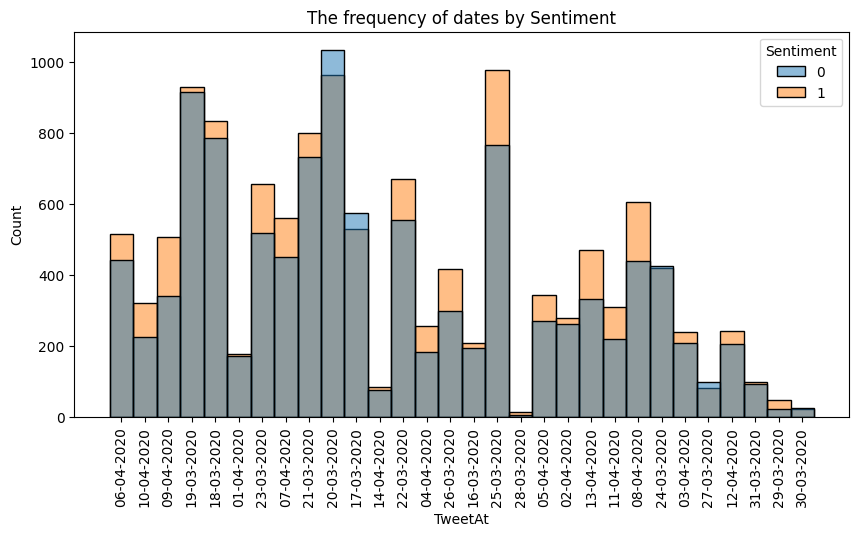

In [ ]:
df['TweetAt'] = pd.to_datetime(df['TweetAt'], format = '%d-%m-%Y')

fig = plt.figure(figsize = (10, 5))
sns.histplot(x=train['TweetAt'], hue=train['Sentiment'])
plt.xticks(rotation=90)
plt.title('The frequency of dates by Sentiment')
plt.show()

**Ответ:** Я думаю, что дата публикования твита в данном случае бесполезна, так как каждый день примерно одинаковое распределение негативных и позитивных твитов. Также, если в будущем нам придут новые данные, то прошлые даты не будут ничего значить для новых данных.

Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [ ]:
print(f'Уникальных значений Location: {train.Location.nunique()} штуки')

Уникальных значений Location: 7949 штуки


Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

In [ ]:
# Unknown - самое популярное, поэтому берем срез с 1
train['Location'].value_counts()

Location
Unknown                           4944
London                             301
United States                      295
London, England                    274
New York, NY                       223
                                  ... 
Work: Kent and Live: Sussex          1
Somewhere on TradingView             1
Honolulu, Hawai?i                    1
SFO                                  1
Waterville, Ireland Austin, TX       1
Name: count, Length: 7949, dtype: int64

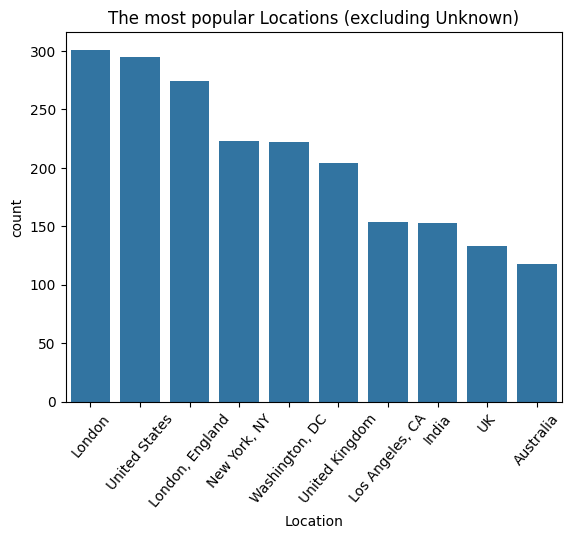

In [ ]:
sns.barplot(train['Location'].value_counts()[1:11])
plt.xticks(rotation=50)
plt.title('The most popular Locations (excluding Unknown)')
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

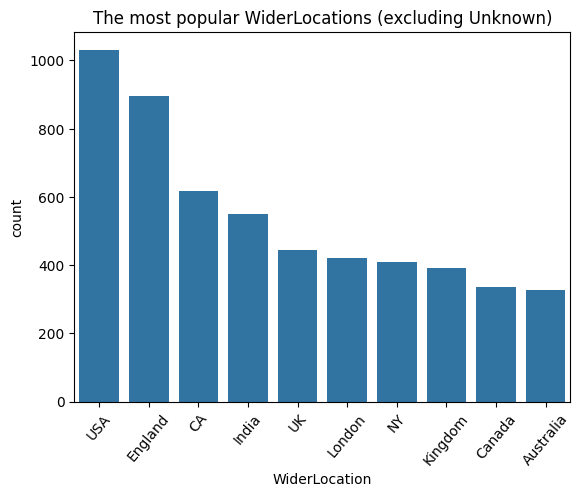

Уникальных категорий стало 3264


In [ ]:
train['WiderLocation'] = train['Location'].apply(lambda x: x.split()[-1] if len(x.split()) > 1 else x)
test['WiderLocation'] = test['Location'].apply(lambda x: x.split()[-1] if len(x.split()) > 1 else x)
sns.barplot(train['WiderLocation'].value_counts()[1:11])
plt.xticks(rotation=50)
plt.title('The most popular WiderLocations (excluding Unknown)')
plt.show()
print(f'Уникальных категорий стало {train.WiderLocation.nunique()}')

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', min_frequency=2)
ohe_train = ohe.fit_transform(pd.DataFrame(train['WiderLocation']))
ohe_test = ohe.transform(pd.DataFrame(test['WiderLocation']))
print(f'Таких значений в train {ohe_train.toarray().shape[1]}')

Таких значений в train 979


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [ ]:
df_vec_train = pd.DataFrame(vector_cv_train_fin, columns=cv_fin.get_feature_names_out())
df_ohe_train = pd.DataFrame(ohe_train.toarray(), columns=ohe.get_feature_names_out())
df_with_locat = pd.concat([df_vec_train, df_ohe_train], axis=1)

In [ ]:
df_vec_test = pd.DataFrame(vector_cv_test_fin, columns=cv_fin.get_feature_names_out())
df_ohe_test = pd.DataFrame(ohe_test.toarray(), columns=ohe.get_feature_names_out())
df_with_locat_test = pd.concat([df_vec_test, df_ohe_test], axis=1)

In [ ]:
clf11 = LogisticRegression(max_iter=500, random_state=0)
clf11.fit(df_with_locat.values, y_train)
pred_train_final = clf11.predict(df_with_locat.values)
pred_test_final = clf11.predict(df_with_locat_test.values)

print(f'Доля правильных ответов на train = {accuracy_score(pred_train_final, y_train)}')
print(f'Доля правильных ответов на test = {accuracy_score(pred_test_final, y_test)}')

Доля правильных ответов на train = 0.9459632635625801
Доля правильных ответов на test = 0.8453258919673111


**Ответ:** В данном случае качество модели на трейне чуть улучшилось, а на тесте чуть ухудшилось. Предполагаю, что модель сильнее подогналась под обучающую выборку за счет учета местоположения; без него качество на тесте лучше, так что признак лучше не использовать.